# 🏠 House Price Prediction
### Regression Model using Scikit-learn

**Goal:** Predict house prices based on features like crime rate,
number of rooms, accessibility etc.

**Tools Used:** Python, NumPy, Pandas, Scikit-learn, Matplotlib

**Models:** Linear Regression

**Evaluation Metrics:** RMSE (Root Mean Squared Error), R² Score

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Loading Dataset & Explore

# Load California Housing Dataset
housing = fetch_california_housing()


# Convert to DataFrame
df = pd.DataFrame(data=housing.data, columns=housing.feature_names)
df['Price'] = housing.target  # Price in $100,000s

print(" Dataset Shape:", df.shape)
print("\n First 5 rows:")
print(df.head())
print("\n Basic Statistics:")
print(df.describe().round(2))
print("\n Missing Values:")
print(df.isnull().sum())


 Dataset Shape: (20640, 9)

 First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

 Basic Statistics:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00  

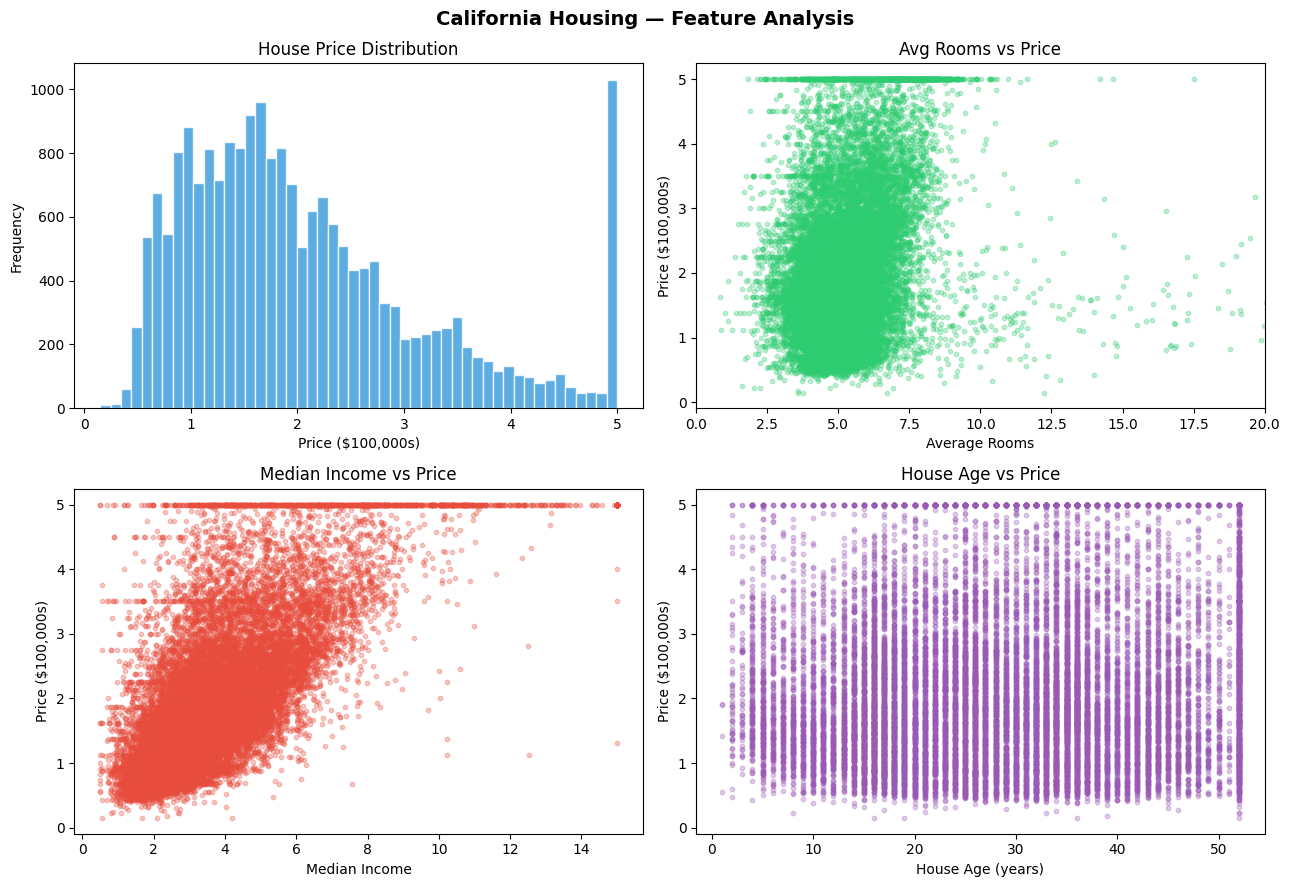

In [3]:

# Data Visualization

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('California Housing — Feature Analysis', fontsize=14, fontweight='bold')

# Plot 1: Price Distribution
axes[0, 0].hist(df['Price'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('House Price Distribution')
axes[0, 0].set_xlabel('Price ($100,000s)')
axes[0, 0].set_ylabel('Frequency')

# Plot 2: Average Rooms vs Price
axes[0, 1].scatter(df['AveRooms'], df['Price'], alpha=0.3, color='#2ecc71', s=10)
axes[0, 1].set_title('Avg Rooms vs Price')
axes[0, 1].set_xlabel('Average Rooms')
axes[0, 1].set_ylabel('Price ($100,000s)')
axes[0, 1].set_xlim(0, 20)

# Plot 3: Median Income vs Price
axes[1, 0].scatter(df['MedInc'], df['Price'], alpha=0.3, color='#e74c3c', s=10)
axes[1, 0].set_title('Median Income vs Price')
axes[1, 0].set_xlabel('Median Income')
axes[1, 0].set_ylabel('Price ($100,000s)')

# Plot 4: House Age vs Price
axes[1, 1].scatter(df['HouseAge'], df['Price'], alpha=0.3, color='#9b59b6', s=10)
axes[1, 1].set_title('House Age vs Price')
axes[1, 1].set_xlabel('House Age (years)')
axes[1, 1].set_ylabel('Price ($100,000s)')

plt.tight_layout()
plt.savefig('feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:

# Data Preprocessing & Train-Test Split

# Features and Target
X = df.drop('Price', axis=1).values
y = df['Price'].values

print(" Features used:", housing.feature_names)
print(f" Total samples: {X.shape[0]}")

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n Training samples : {X_train.shape[0]}")
print(f" Testing samples  : {X_test.shape[0]}")
print(f" Features         : {X_train.shape[1]}")
print("\n Features normalized using StandardScaler")

 Features used: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
 Total samples: 20640

 Training samples : 16512
 Testing samples  : 4128
 Features         : 8

 Features normalized using StandardScaler


In [7]:

# Train Linear Regression Model

# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

# Model 2: Ridge Regression (handles overfitting)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_preds = ridge.predict(X_test_scaled)

# Metrics
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  {name}")
    print(f"    RMSE : {rmse:.4f}  (lower is better)")
    print(f"    R²   : {r2:.4f}  (closer to 1 is better)")
    print()
    return rmse, r2

print("=" * 45)
print("               MODEL EVALUATION")
print("=" * 45)
lr_rmse,    lr_r2    = evaluate("Linear Regression", y_test, lr_preds)
ridge_rmse, ridge_r2 = evaluate("Ridge Regression",  y_test, ridge_preds)

               MODEL EVALUATION
  Linear Regression
    RMSE : 0.7456  (lower is better)
    R²   : 0.5758  (closer to 1 is better)

  Ridge Regression
    RMSE : 0.7456  (lower is better)
    R²   : 0.5758  (closer to 1 is better)



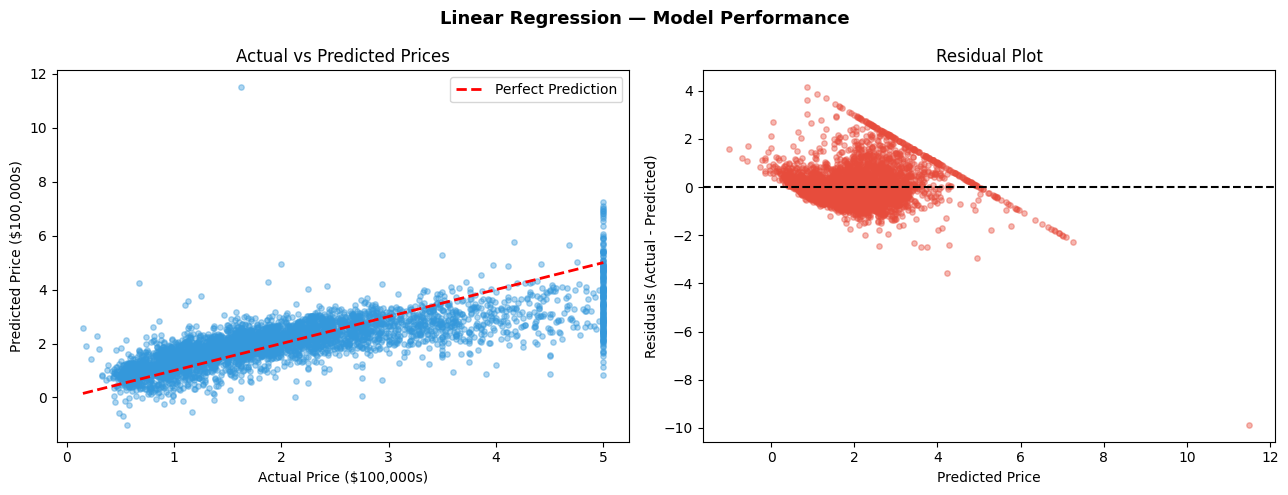

 Prediction plots saved!


In [8]:

# Actual vs Predicted values & Residuals

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Linear Regression — Model Performance', fontsize=13, fontweight='bold')

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, lr_preds, alpha=0.4, color='#3498db', s=15)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title('Actual vs Predicted Prices')
axes[0].set_xlabel('Actual Price ($100,000s)')
axes[0].set_ylabel('Predicted Price ($100,000s)')
axes[0].legend()

# Plot 2: Residuals
residuals = y_test - lr_preds
axes[1].scatter(lr_preds, residuals, alpha=0.4, color='#e74c3c', s=15)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Prediction plots saved!")

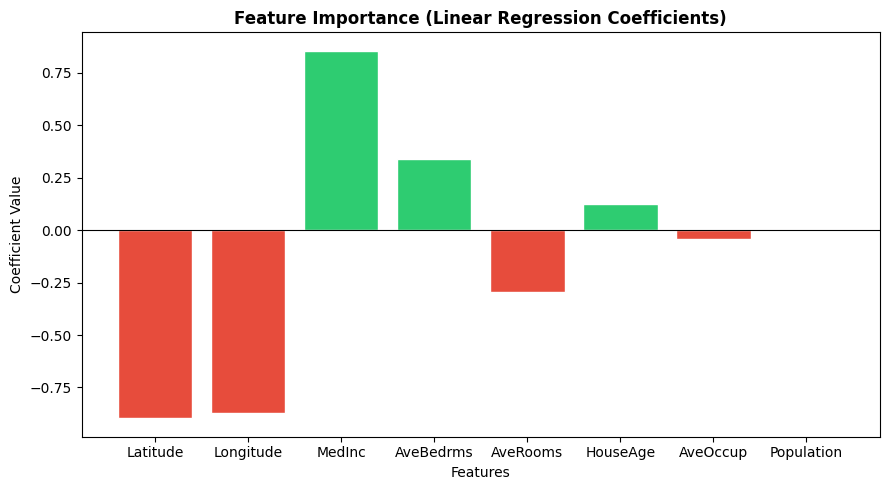


 Feature Importance Ranking:
  Latitude     : -0.8969  (↓ decreases price)
  Longitude    : -0.8698  (↓ decreases price)
  MedInc       : +0.8544  (↑ increases price)
  AveBedrms    : +0.3393  (↑ increases price)
  AveRooms     : -0.2944  (↓ decreases price)
  HouseAge     : +0.1225  (↑ increases price)
  AveOccup     : -0.0408  (↓ decreases price)
  Population   : -0.0023  (↓ decreases price)


In [9]:

# Feature Importance (Coefficients)

feature_names = housing.feature_names
coefficients  = lr.coef_

# Sort by absolute importance
sorted_idx  = np.argsort(np.abs(coefficients))[::-1]
sorted_coef = coefficients[sorted_idx]
sorted_feat = [feature_names[i] for i in sorted_idx]

plt.figure(figsize=(9, 5))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in sorted_coef]
bars = plt.bar(sorted_feat, sorted_coef, color=colors, edgecolor='white')
plt.title('Feature Importance (Linear Regression Coefficients)',
          fontsize=12, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Feature Importance Ranking:")
for feat, coef in zip(sorted_feat, sorted_coef):
    direction = "↑ increases" if coef > 0 else "↓ decreases"
    print(f"  {feat:12s} : {coef:+.4f}  ({direction} price)")

In [10]:

# Summary

print("=" * 52)
print("      PROJECT SUMMARY — HOUSE PRICE PREDICTION")
print("=" * 52)
print(f"  Dataset         : California Housing (20,640 samples)")
print(f"  Features        : {X.shape[1]} (income, rooms, age etc.)")
print(f"  Train/Test      : {X_train.shape[0]} / {X_test.shape[0]} samples")
print(f"  Preprocessing   : StandardScaler normalization")
print()
print(f"  Linear Regression:")
print(f"    RMSE          : {lr_rmse:.4f}")
print(f"    R² Score      : {lr_r2:.4f}")
print()
print(f"  Ridge Regression:")
print(f"    RMSE          : {ridge_rmse:.4f}")
print(f"    R² Score      : {ridge_r2:.4f}")
print()
print(f"  Best Model      : {'Linear Regression' if lr_r2 >= ridge_r2 else 'Ridge Regression'}")
print("=" * 52)


      PROJECT SUMMARY — HOUSE PRICE PREDICTION
  Dataset         : California Housing (20,640 samples)
  Features        : 8 (income, rooms, age etc.)
  Train/Test      : 16512 / 4128 samples
  Preprocessing   : StandardScaler normalization

  Linear Regression:
    RMSE          : 0.7456
    R² Score      : 0.5758

  Ridge Regression:
    RMSE          : 0.7456
    R² Score      : 0.5758

  Best Model      : Ridge Regression
